Make sure where dataset will be created is empty

In [ ]:
import shutil, os

target = "/content/-f"
if os.path.exists(target):
    shutil.rmtree(target)
    print("Deleted existing dataset folder:", target)
else:
    print("No existing dataset found at", target)


Deleted existing dataset folder: /content/-f


Create Dataset of ASCII Binary Images

In [ ]:
# save as generate_binary_images.py
# Requirements: pillow, numpy, opencv-python
# python generate_binary_images.py out_dir  -- will create images and labels.csv

import os, sys, csv, random
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import cv2

OUT = Path(sys.argv[1] if len(sys.argv)>1 else "binary_dataset")
OUT.mkdir(parents=True, exist_ok=True)
LABELS_CSV = OUT / "labels.csv"

# chars to include (printable ASCII subset)
chars = [chr(c) for c in range(32, 127)]  # space through ~
fonts = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
]
fonts = [f for f in fonts if Path(f).exists()]
if not fonts:
    # fallback to default PIL font
    fonts = [None]

def ascii_to_bits(ch):
    return format(ord(ch), '08b')

def render_binary_string(binstr, font_path, font_size=36, pad=8):
    # create image white background
    if font_path:
        font = ImageFont.truetype(font_path, font_size)
    else:
        font = ImageFont.load_default()
    # compute text size using bounding box
    dummy = Image.new("L", (1, 1))
    draw = ImageDraw.Draw(dummy)
    bbox = draw.textbbox((0, 0), binstr, font=font)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]

    img = Image.new("L", (w + pad*2, h + pad*2), 255)
    draw = ImageDraw.Draw(img)
    draw.text((pad, pad), binstr, font=font, fill=0)

    return np.array(img)

def augment(img):
    # img: numpy array grayscale
    # random blur
    if random.random() < 0.3:
        k = random.choice([3,5])
        img = cv2.GaussianBlur(img, (k,k), 0)
    # random rotation small angle
    if random.random() < 0.5:
        angle = random.uniform(-6,6)
        (h,w) = img.shape
        M = cv2.getRotationMatrix2D((w//2,h//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w,h), borderValue=255)
    # random salt & pepper
    if random.random() < 0.25:
        prob = random.uniform(0.001, 0.01)
        rn = np.random.rand(*img.shape)
        img[rn < prob/2] = 0
        img[rn > 1 - prob/2] = 255
    # random resize + pad to fixed size
    target_h = 48
    scale = target_h / img.shape[0]
    nw = max(1, int(img.shape[1] * scale))
    img = cv2.resize(img, (nw, target_h), interpolation=cv2.INTER_AREA)
    # pad width to 200
    W = 200
    if nw < W:
      max_left = max(0, min(20, W - nw))
      pad_left = random.randint(0, max_left) if max_left > 0 else 0
      pad_right = max(0, W - nw - pad_left)
      img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, cv2.BORDER_CONSTANT, value=255)
    else:
      img = cv2.resize(img, (W, target_h), interpolation=cv2.INTER_AREA)

    return img

# generation parameters
per_char = 25  # images per character (adjust)
out_images = []
with open(LABELS_CSV, 'w', newline='') as csvf:
    writer = csv.writer(csvf)
    writer.writerow(["filename","char","ascii_code","binary"])
    idx = 0
    for ch in chars:
        bits = ascii_to_bits(ch)
        for i in range(per_char):
            font_path = random.choice(fonts)
            fs = random.choice([28,32,36,40])
            raw = render_binary_string(bits, font_path, font_size=fs)
            img = augment(raw)
            # threshold to make binary pixels 0/255
            _, img = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)
            fname = f"{idx:06d}.png"
            cv2.imwrite(str(OUT / fname), img)
            writer.writerow([fname, ch, ord(ch), bits])
            idx += 1
print("done. images:", idx, "saved to", OUT)


done. images: 2375 saved to -f


Load Dataset to Google Drive for future use

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Define the source directory (where the dataset was created) and the destination in Google Drive
source_dir = '/content/-f'
destination_dir = '/content/drive/MyDrive/Dataset'

# Ensure the destination directory exists in Google Drive
!mkdir -p "$destination_dir"

# Move the generated dataset directory to Google Drive
!mv -f "$source_dir" "$destination_dir"

Mounted at /content/drive
mv: cannot stat '/content/-f': No such file or directory


CNN Model for Binary ASCII Dataset

In [ ]:
# train_binary_ascii_cnn_regularized_fixed.py
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# ---------------- Dataset ----------------
class BinaryASCIIDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        print("[INFO] Initializing dataset...")
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform
        self.le = LabelEncoder()
        self.data["label_idx"] = self.le.fit_transform(self.data["char"])
        self.labels = self.data["label_idx"].values
        print(f"[INFO] Loaded {len(self.data)} samples from {csv_path}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# ---------------- Model ----------------
class BinaryToASCIICNN(nn.Module):
    def __init__(self, num_classes):
        super(BinaryToASCIICNN, self).__init__()
        print("[INFO] Initializing CNN model...")
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 25, 512),  # adjust to image size after pooling
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        print("[INFO] CNN model initialized successfully.")

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ---------------- Evaluation ----------------
def evaluate(model, loader, device, criterion):
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    acc = 100 * correct / total
    avg_loss = val_loss / len(loader)
    return avg_loss, acc

# ---------------- Training ----------------
def train_model(model, train_loader, val_loader, device, epochs=40, lr=0.0008):
    print("[INFO] Starting training...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    best_val_acc = 0.0

    for epoch in range(epochs):
        print(f"\n[INFO] Epoch {epoch+1}/{epochs} starting...")
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        val_loss, val_acc = evaluate(model, val_loader, device, criterion)
        scheduler.step(val_acc)

        print(f"[EPOCH {epoch+1:02d}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
              f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "model_state": model.state_dict(),
                "label_encoder": train_loader.dataset.dataset.le.classes_
            }, "binary_ascii_cnn_regularized_best.pth")
            print("[INFO] Model improved and saved.")

    print("[INFO] Training complete.")

# ---------------- Main ----------------
if __name__ == "__main__":
    print("[INFO] Starting main execution...")
    dataset_dir = "/content/drive/MyDrive/Dataset/-f"
    csv_path = os.path.join(dataset_dir, "labels.csv")

    print("[INFO] Setting up image transformations...")
    transform = transforms.Compose([
        transforms.Resize((48, 200)),
        transforms.RandomRotation(2),
        transforms.RandomAffine(0, translate=(0.02, 0.02)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    print("[INFO] Loading dataset...")
    full_dataset = BinaryASCIIDataset(csv_path, dataset_dir, transform)

    print("[INFO] Splitting dataset into train/validation sets...")
    train_idx, val_idx = train_test_split(
        np.arange(len(full_dataset)), test_size=0.2,
        stratify=full_dataset.labels, random_state=42
    )
    train_subset = torch.utils.data.Subset(full_dataset, train_idx)
    val_subset = torch.utils.data.Subset(full_dataset, val_idx)

    print("[INFO] Creating data loaders...")
    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Using device: {device}")
    model = BinaryToASCIICNN(num_classes=len(full_dataset.le.classes_)).to(device)

    train_model(model, train_loader, val_loader, device, epochs=40, lr=0.0008)

    print("[INFO] Saving final model checkpoint...")
    torch.save({
        "model_state": model.state_dict(),
        "label_encoder": full_dataset.le.classes_
    }, "binary_ascii_cnn_regularized_final.pth")

    print("[INFO] Model saved as binary_ascii_cnn_regularized_final.pth")

[INFO] Starting main execution...
[INFO] Setting up image transformations...
[INFO] Loading dataset...
[INFO] Initializing dataset...
[INFO] Loaded 2375 samples from /content/drive/MyDrive/Dataset/-f/labels.csv
[INFO] Splitting dataset into train/validation sets...
[INFO] Creating data loaders...
[INFO] Using device: cuda
[INFO] Initializing CNN model...
[INFO] CNN model initialized successfully.
[INFO] Starting training...

[INFO] Epoch 1/40 starting...
[EPOCH 01] Train Loss: 6.6745 | Train Acc: 1.53% | Val Loss: 4.4031 | Val Acc: 1.26%
[INFO] Model improved and saved.

[INFO] Epoch 2/40 starting...
[EPOCH 02] Train Loss: 4.2848 | Train Acc: 3.47% | Val Loss: 3.9732 | Val Acc: 8.00%
[INFO] Model improved and saved.

[INFO] Epoch 3/40 starting...
[EPOCH 03] Train Loss: 3.8502 | Train Acc: 7.42% | Val Loss: 3.3917 | Val Acc: 14.53%
[INFO] Model improved and saved.

[INFO] Epoch 4/40 starting...
[EPOCH 04] Train Loss: 3.4284 | Train Acc: 11.58% | Val Loss: 2.8275 | Val Acc: 24.21%
[INFO]

Making a smaller dataset of 200 new binary ASCII images and stores them for future use

In [ ]:
# save as generate_binary_images_subset.py
# Generates 200 random binary ASCII images and saves them + labels.csv to Google Drive

import os, csv, random
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import cv2
from google.colab import drive

# ------------------ Setup ------------------
print("[INFO] Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

OUT = Path("/content/drive/MyDrive/Dataset/UsingModel")
OUT.mkdir(parents=True, exist_ok=True)
LABELS_CSV = OUT / "labels.csv"

print(f"[INFO] Output directory set to: {OUT}")

# ------------------ Character set and fonts ------------------
chars = [chr(c) for c in range(32, 127)]  # printable ASCII
fonts = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf"
]
fonts = [f for f in fonts if Path(f).exists()]
if not fonts:
    fonts = [None]  # fallback

# ------------------ Helper functions ------------------
def ascii_to_bits(ch):
    return format(ord(ch), '08b')

def render_binary_string(binstr, font_path, font_size=36, pad=8):
    if font_path:
        font = ImageFont.truetype(font_path, font_size)
    else:
        font = ImageFont.load_default()
    dummy = Image.new("L", (1, 1))
    draw = ImageDraw.Draw(dummy)
    bbox = draw.textbbox((0, 0), binstr, font=font)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    img = Image.new("L", (w + pad*2, h + pad*2), 255)
    draw = ImageDraw.Draw(img)
    draw.text((pad, pad), binstr, font=font, fill=0)
    return np.array(img)

def augment(img):
    if random.random() < 0.3:
        k = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)
    if random.random() < 0.5:
        angle = random.uniform(-6, 6)
        (h, w) = img.shape
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    if random.random() < 0.25:
        prob = random.uniform(0.001, 0.01)
        rn = np.random.rand(*img.shape)
        img[rn < prob / 2] = 0
        img[rn > 1 - prob / 2] = 255
    target_h = 48
    scale = target_h / img.shape[0]
    nw = max(1, int(img.shape[1] * scale))
    img = cv2.resize(img, (nw, target_h), interpolation=cv2.INTER_AREA)
    W = 200
    if nw < W:
        max_left = max(0, min(20, W - nw))
        pad_left = random.randint(0, max_left) if max_left > 0 else 0
        pad_right = max(0, W - nw - pad_left)
        img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, cv2.BORDER_CONSTANT, value=255)
    else:
        img = cv2.resize(img, (W, target_h), interpolation=cv2.INTER_AREA)
    return img

# ------------------ Generation ------------------
print("[INFO] Generating 200 random binary ASCII images...")
total_images = 200
out_images = []

with open(LABELS_CSV, 'w', newline='') as csvf:
    writer = csv.writer(csvf)
    writer.writerow(["filename", "char", "ascii_code", "binary"])
    for idx in range(total_images):
        ch = random.choice(chars)
        bits = ascii_to_bits(ch)
        font_path = random.choice(fonts)
        fs = random.choice([28, 32, 36, 40])
        raw = render_binary_string(bits, font_path, font_size=fs)
        img = augment(raw)
        _, img = cv2.threshold(img, 200, 255, cv2.THRESH_BINARY)

        fname = f"{idx:06d}.png"
        cv2.imwrite(str(OUT / fname), img)
        writer.writerow([fname, ch, ord(ch), bits])

        if (idx + 1) % 25 == 0 or idx == total_images - 1:
            print(f"[INFO] Generated {idx + 1}/{total_images} images")

print(f"[INFO] Done. Generated {total_images} images and labels.csv in {OUT}")


[INFO] Mounting Google Drive...
Mounted at /content/drive
[INFO] Output directory set to: /content/drive/MyDrive/Dataset/UsingModel
[INFO] Generating 200 random binary ASCII images...
[INFO] Generated 25/200 images
[INFO] Generated 50/200 images
[INFO] Generated 75/200 images
[INFO] Generated 100/200 images
[INFO] Generated 125/200 images
[INFO] Generated 150/200 images
[INFO] Generated 175/200 images
[INFO] Generated 200/200 images
[INFO] Done. Generated 200 images and labels.csv in /content/drive/MyDrive/Dataset/UsingModel


Testing the model using a separate smaller dataset, Evaluating and displaying the results

[INFO] Starting evaluation script...
[INFO] Using device: cuda
[INFO] Loading saved model checkpoint...
[INFO] Loaded model with 95 label classes.
[INFO] Setting up image transformations...
[INFO] Initializing dataset and dataloader...
[INFO] Loading dataset from: /content/drive/MyDrive/Dataset/UsingModel/labels.csv
[INFO] Dataset initialized with 200 samples and 95 classes.
[INFO] DataLoader created with 7 batches.
[INFO] Initializing model and loading weights...
[INFO] Initializing CNN model for evaluation...
[INFO] CNN model initialized successfully.
[INFO] Model weights loaded successfully.

[INFO] Starting evaluation...
[STEP] Evaluating batch 1/7...
[STEP] Evaluating batch 5/7...
[INFO] Evaluation complete. Calculating metrics...

--- Individual Predictions ---
Predicted: u | Actual: *
Predicted: \ | Actual: \
Predicted: l | Actual: l
Predicted: 3 | Actual: :
Predicted: / | Actual: /
Predicted: ] | Actual: ]
Predicted: { | Actual: =
Predicted: E | Actual: C
Predicted: } | Actual:

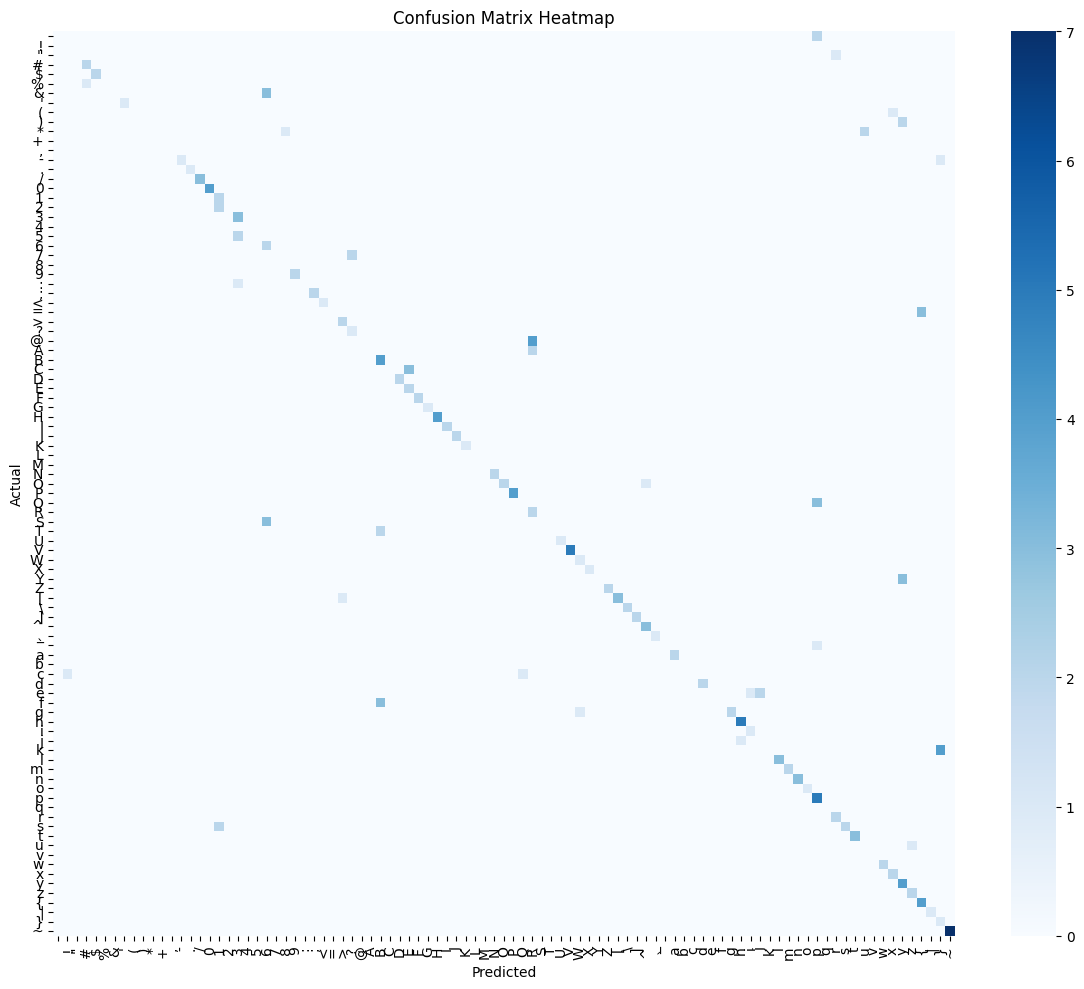

In [ ]:
# evaluate_binary_ascii_cnn_regularized_fixed.py
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---------------- Dataset ----------------
class BinaryASCIIDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, classes=None):
        print("[INFO] Loading dataset from:", csv_path)
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

        self.le = LabelEncoder()
        if classes is not None:
            # use the same classes as training
            self.le.classes_ = np.array(classes)
        else:
            # fallback (should not happen if you pass classes)
            self.le.fit(self.data["char"])
        # Map char → index using the known classes
        char2idx = {c: i for i, c in enumerate(self.le.classes_)}
        self.data["label_idx"] = self.data["char"].map(char2idx)
        # Optionally handle chars not found in classes
        missing = self.data["label_idx"].isna().sum()
        if missing:
            print(f"[WARNING] {missing} samples had chars outside training classes and will be set to -1 label.")
            self.data["label_idx"] = self.data["label_idx"].fillna(-1).astype(int)
        self.labels = self.data["label_idx"].values
        print(f"[INFO] Dataset initialized with {len(self.data)} samples and {len(self.le.classes_)} classes.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        label = self.labels[idx]
        return image, label

# ---------------- Model ----------------
class BinaryToASCIICNN(nn.Module):
    def __init__(self, num_classes):
        super(BinaryToASCIICNN, self).__init__()
        print("[INFO] Initializing CNN model for evaluation...")
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # NOTE: adjust linear input dims if you change input image size or pooling
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 25, 512),  # matches 48×200 input after 3×2 pooling
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        print("[INFO] CNN model initialized successfully.")

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# ---------------- Evaluation ----------------
def evaluate_model(model, loader, device, label_encoder_classes):
    print("[INFO] Starting evaluation...")
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            if (batch_idx + 1) % 5 == 0 or batch_idx == 0:
                print(f"[STEP] Evaluating batch {batch_idx+1}/{len(loader)}...")
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print("[INFO] Evaluation complete. Calculating metrics...")

    # Filter out samples with invalid label (-1)
    valid_idx = [i for i, t in enumerate(y_true) if t >= 0]
    y_true_valid = [y_true[i] for i in valid_idx]
    y_pred_valid = [y_pred[i] for i in valid_idx]

    # Convert indices to characters using label_encoder_classes
    classes = label_encoder_classes
    y_true_chars = [classes[i] for i in y_true_valid]
    y_pred_chars = [classes[i] for i in y_pred_valid]

    # Print a few sample predictions
    print("\n--- Individual Predictions ---")
    for true_c, pred_c in zip(y_true_chars[:25], y_pred_chars[:25]):
        print(f"Predicted: {pred_c} | Actual: {true_c}")

    # Compute metrics
    acc = accuracy_score(y_true_valid, y_pred_valid)
    prec = precision_score(y_true_valid, y_pred_valid, average='macro', zero_division=0)
    rec = recall_score(y_true_valid, y_pred_valid, average='macro', zero_division=0)
    f1 = f1_score(y_true_valid, y_pred_valid, average='macro', zero_division=0)
    cm = confusion_matrix(y_true_valid, y_pred_valid, labels=list(range(len(classes))))

    print("\n--- Summary ---")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall   : {rec*100:.2f}%")
    print(f"F1-Score : {f1*100:.2f}%")

    print("\nClassification Report:")
    print(classification_report(
        y_true_valid, y_pred_valid,
        labels=list(range(len(classes))),
        target_names=classes,
        zero_division=0
    ))

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, annot=False, cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix Heatmap")
    plt.tight_layout()
    plt.show()

# ---------------- Main ----------------
if __name__ == "__main__":
    print("[INFO] Starting evaluation script...")
    dataset_dir = "/content/drive/MyDrive/Dataset/UsingModel"
    csv_path = os.path.join(dataset_dir, "labels.csv")
    model_path = "/content/binary_ascii_cnn_regularized_final.pth"

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[INFO] Using device: {device}")

    print("[INFO] Loading saved model checkpoint...")
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    saved_classes = checkpoint["label_encoder"]
    print(f"[INFO] Loaded model with {len(saved_classes)} label classes.")

    print("[INFO] Setting up image transformations...")
    transform = transforms.Compose([
        transforms.Resize((48, 200)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    print("[INFO] Initializing dataset and dataloader...")
    dataset = BinaryASCIIDataset(csv_path, dataset_dir, transform, classes=saved_classes)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    print(f"[INFO] DataLoader created with {len(loader)} batches.")

    print("[INFO] Initializing model and loading weights...")
    model = BinaryToASCIICNN(num_classes=len(saved_classes)).to(device)
    model.load_state_dict(checkpoint["model_state"])
    print("[INFO] Model weights loaded successfully.\n")

    evaluate_model(model, loader, device, saved_classes)